In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBClassifier

In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

cleaned_file = project_root / "data" / "processed" / "student_dropout_cleaned.csv"

df = pd.read_csv(cleaned_file)

second_sem_features = [col for col in df.columns if "2nd_sem" in col]
df_first_sem = df.drop(columns=second_sem_features)

X = df_first_sem.drop(columns=["dropout_risk"])
y = df_first_sem["dropout_risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3630, 30)
y shape: (3630,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2904, 30)
X_test: (726, 30)


In [4]:
model_path = project_root / "models" / "xgboost_first_semester_model.json"

xgb_first_sem_model = XGBClassifier()
xgb_first_sem_model.load_model(model_path)

print("First-semester XGBoost model loaded successfully.")

First-semester XGBoost model loaded successfully.


In [5]:
explainer = shap.TreeExplainer(xgb_first_sem_model)

print("TreeSHAP explainer created successfully.")

TreeSHAP explainer created successfully.


In [6]:
shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")
print("SHAP values shape:", shap_values.shape)

SHAP values generated.
SHAP values shape: (726, 30)


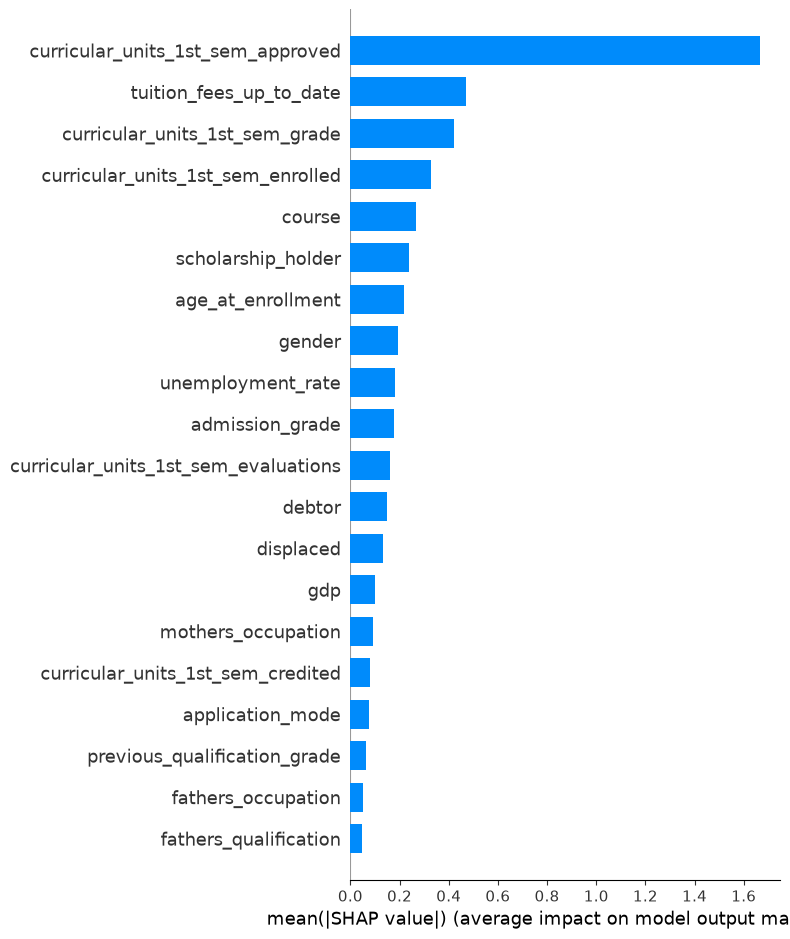

In [7]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

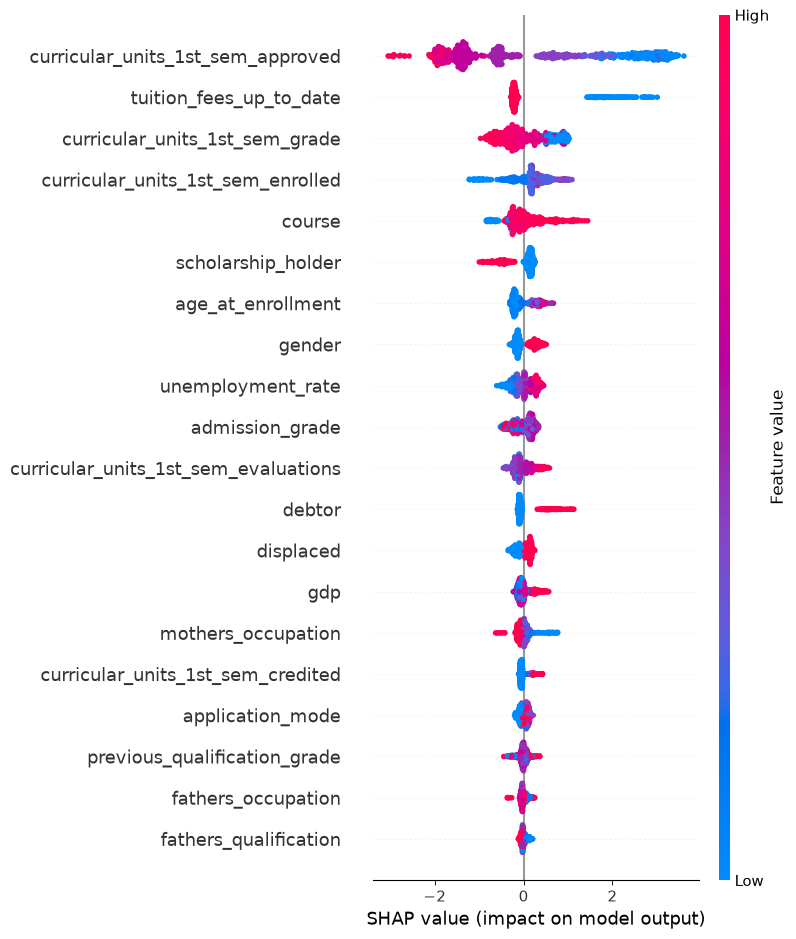

In [8]:
shap.summary_plot(shap_values, X_test)

In [9]:
import numpy as np

shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap_value": np.abs(shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap_value", ascending=False)

results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

shap_importance.to_csv(results_path / "treeshap_first_semester_feature_importance.csv", index=False)

shap_importance.head(15)

,feature,mean_abs_shap_value
24,curricular_units_1st_sem_approved,1.664232
16,tuition_fees_up_to_date,0.471833
25,curricular_units_1st_sem_grade,0.420645
22,curricular_units_1st_sem_enrolled,0.329597
3,course,0.265145
18,scholarship_holder,0.238178
19,age_at_enrollment,0.219417
17,gender,0.193336
27,unemployment_rate,0.179837
12,admission_grade,0.178680


Actual label: 0
Predicted probability: 0.030204656


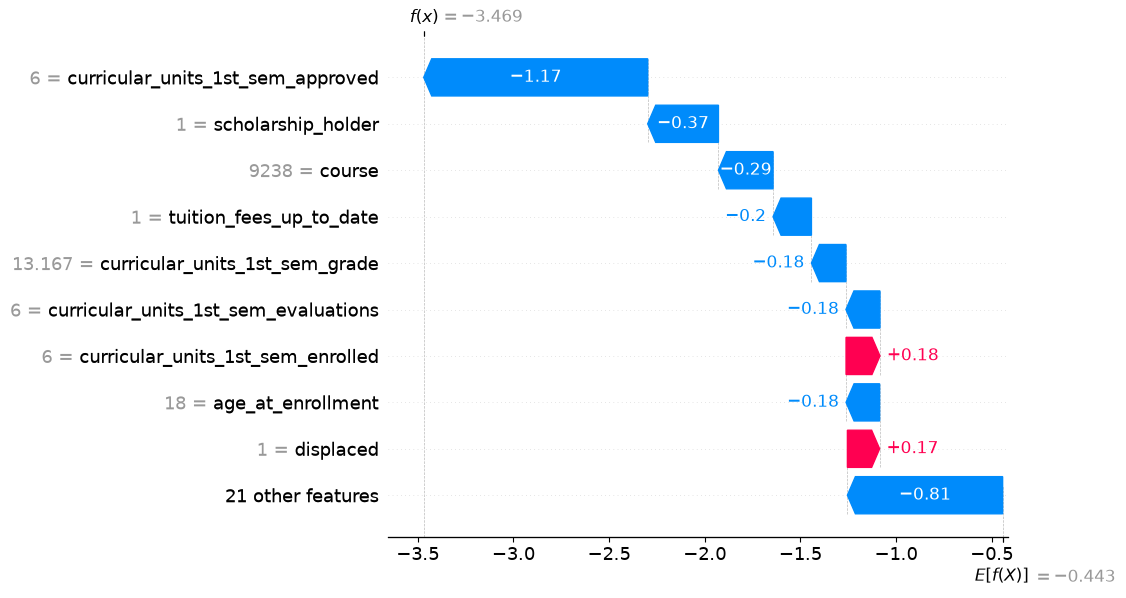

In [10]:
student_index = 0

print("Actual label:", y_test.iloc[student_index])
print("Predicted probability:", xgb_first_sem_model.predict_proba(X_test.iloc[[student_index]])[:, 1][0])

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[student_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[student_index],
        feature_names=X_test.columns
    )
)